In [83]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import MinMaxScaler


In [84]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [85]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [86]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [87]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [88]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [89]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [90]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [91]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [92]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [93]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event


In [94]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [95]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [96]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [97]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [98]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Standardization for Clustering

In [99]:
original_X = X.copy()

In [100]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']
### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical using the min max scaling
scaler = MinMaxScaler()  
X_numeric_std = scaler.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

# Clustering

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

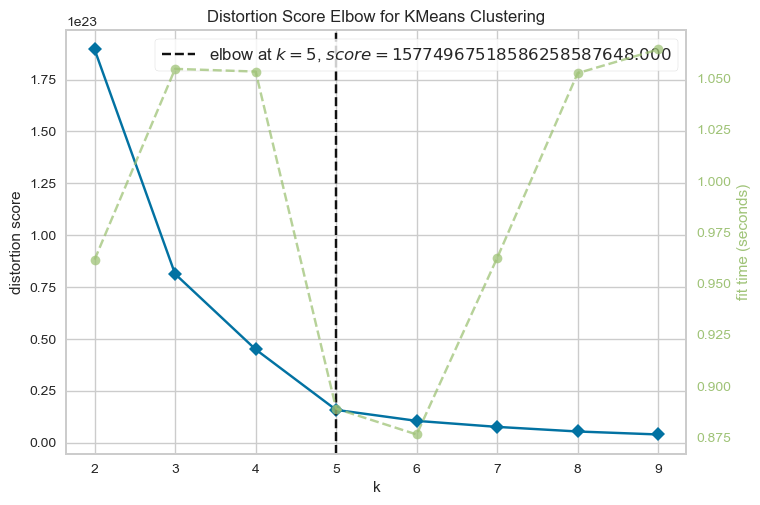

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [101]:
# Decide how many clusters to form 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [102]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['OS', 'event_OS']]], axis=1)
    coxph.fit(X_cluster, duration_col='OS', event_col='event_OS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 0: Most important feature: glrlm_GrayLevelVariance_CT_b20, Coefficient: 18.04942132456842


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 1: Most important feature: gldm_HighGrayLevelEmphasis_d_1_CT_c16, Coefficient: -13.604689367606506


...

Cluster 2: Most important feature: gldm_GrayLevelNonUniformity_d_1_PET_c04, Coefficient: -43.84647746623108


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 3: Most important feature: glcm_Autocorrelation_d_1_CT_b20, Coefficient: -8.22017122245359


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 4: Most important feature: first_order_Entropy_PET_b2, Coefficient: -10.258483737081606


In [103]:
# Selecting features in the DataFrame
X_fs_fi = X[selected_features]
X_new = X_fs_fi.copy()

X_MAASTRO_fs_fi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_fi.copy()

# Standardization

In [104]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = MinMaxScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [105]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [106]:
X_new

,glrlm_GrayLevelVariance_CT_b20,gldm_HighGrayLevelEmphasis_d_1_CT_c16,gldm_GrayLevelNonUniformity_d_1_PET_c04,glcm_Autocorrelation_d_1_CT_b20,first_order_Entropy_PET_b2
0,22.310788,93.931911,2305.801653,2024.127331,2.891638
1,20.557318,119.398184,487.679707,1273.080749,1.765451
2,21.092104,115.381455,4412.632895,2688.489673,1.944295
3,22.786001,163.234342,618.164519,2081.055438,1.072123
4,29.182742,206.510961,765.098047,1795.967423,1.631741
...,...,...,...,...,...
134,4.906583,169.232304,1343.014421,846.398938,2.305276
135,16.015030,80.531748,3826.434004,1640.501203,1.697159
136,24.706900,118.671714,2529.951051,1564.244432,2.643138
137,5.157909,196.953388,2584.183306,1055.251277,1.779428


In [107]:
X_new_std

,glrlm_GrayLevelVariance_CT_b20,gldm_HighGrayLevelEmphasis_d_1_CT_c16,gldm_GrayLevelNonUniformity_d_1_PET_c04,glcm_Autocorrelation_d_1_CT_b20,first_order_Entropy_PET_b2
0,0.072353,0.358598,0.023143,0.620835,0.752418
1,0.066055,0.464356,0.003685,0.385397,0.410634
2,0.067975,0.447675,0.045691,0.829100,0.464911
3,0.074060,0.646401,0.005082,0.638681,0.200217
4,0.097036,0.826122,0.006654,0.549311,0.370054
...,...,...,...,...,...
134,0.009840,0.671309,0.012839,0.251640,0.574464
135,0.049739,0.302950,0.039418,0.500576,0.389908
136,0.080959,0.461339,0.025542,0.476671,0.677001
137,0.010743,0.786431,0.026123,0.317111,0.414876


In [108]:
MAASTRO_new

,glrlm_GrayLevelVariance_CT_b20,gldm_HighGrayLevelEmphasis_d_1_CT_c16,gldm_GrayLevelNonUniformity_d_1_PET_c04,glcm_Autocorrelation_d_1_CT_b20,first_order_Entropy_PET_b2
0,14.212485,191.354768,5138.159229,1491.330500,2.937924
1,54.975356,96.743052,4350.526621,2979.095303,2.007821
2,27.032891,188.107697,2952.642003,1991.788394,2.781184
3,146.781623,89.452126,2345.544757,3019.885590,2.172086
4,9.468732,112.193823,4599.704630,2202.694259,2.075742
...,...,...,...,...,...
94,40.637943,48.789895,2275.176603,1982.818842,3.950830
95,143.812625,171.261283,3627.309673,2668.843896,2.442422
96,22.317077,196.941562,7085.656000,2863.172225,1.793062
97,20.533289,103.424583,4058.888181,2064.421825,2.796474


In [109]:
MAASTRO_new_std

,glrlm_GrayLevelVariance_CT_b20,gldm_HighGrayLevelEmphasis_d_1_CT_c16,gldm_GrayLevelNonUniformity_d_1_PET_c04,glcm_Autocorrelation_d_1_CT_b20,first_order_Entropy_PET_b2
0,0.043265,0.763181,0.053456,0.453814,0.766465
1,0.189678,0.370273,0.045027,0.920199,0.484190
2,0.089314,0.749696,0.030066,0.610697,0.718897
3,0.519430,0.339995,0.023569,0.932986,0.534043
4,0.026226,0.434437,0.047693,0.676812,0.504803
...,...,...,...,...,...
94,0.138181,0.171131,0.022815,0.607886,1.073870
95,0.508766,0.679736,0.037287,0.822941,0.616086
96,0.072375,0.786382,0.074299,0.883859,0.419013
97,0.065968,0.398020,0.041905,0.633467,0.723537


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [110]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-17 16:35:56,445] A new study created in memory with name: no-name-89618c35-0f9c-41cb-a7ee-1aa20a710568


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6017316017316018
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.7058823529411765
Fold 4 C-index: 0.7426160337552743


[I 2024-04-17 16:35:56,929] A new study created in memory with name: no-name-f3ddd7d2-5d05-4b2c-aaf8-9f46dbc21ecf


Fold 5 C-index: 0.6619718309859155
[I 2024-04-17 16:35:56,921] Trial 0 finished with value: 0.6844046495970793 and parameters: {}. Best is trial 0 with value: 0.6844046495970793.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6844046495970793], datetime_start=datetime.datetime(2024, 4, 17, 16, 35, 56, 487943), datetime_complete=datetime.datetime(2024, 4, 17, 16, 35, 56, 921107), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6844046495970793


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.20815915793671164
Fold 2 IBS: 0.17952855025454934
Fold 3 IBS: 0.17658475637846727
Fold 4 IBS: 0.18903257093987189
Fold 5 IBS: 0.228391782120009
[I 2024-04-17 16:35:57,510] Trial 0 finished with value: 0.19633936352592182 and parameters: {}. Best is trial 0 with value: 0.19633936352592182.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.19633936352592182], datetime_start=datetime.datetime(2024, 4, 17, 16, 35, 56, 970976), datetime_complete=datetime.datetime(2024, 4, 17, 16, 35, 57, 510479), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.19633936352592182


In [111]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [112]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.684
train_ibs:  0.196


#### Test

In [113]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [114]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.642
IBS score: 0.204


In [115]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [116]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [117]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 16:35:57,835] A new study created in memory with name: no-name-ee3d39f4-e68b-4a05-b222-7bc829872b0e


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5844155844155844


[I 2024-04-17 16:35:58,116] A new study created in memory with name: no-name-73a6fe97-37fb-4191-986b-d718b438f31a


Fold 2 C-index: 0.6763392857142857
Fold 3 C-index: 0.6519607843137255
Fold 4 C-index: 0.7616033755274262
Fold 5 C-index: 0.6056338028169014
[I 2024-04-17 16:35:58,096] Trial 0 finished with value: 0.6559905665575847 and parameters: {}. Best is trial 0 with value: 0.6559905665575847.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6559905665575847], datetime_start=datetime.datetime(2024, 4, 17, 16, 35, 57, 893108), datetime_complete=datetime.datetime(2024, 4, 17, 16, 35, 58, 96651), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6559905665575847


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397652135259654
Fold 2 IBS: 0.22157791582911082
Fold 3 IBS: 0.20453594627693092
Fold 4 IBS: 0.2247380393362569
Fold 5 IBS: 0.2181243152631878
[I 2024-04-17 16:35:58,418] Trial 0 finished with value: 0.2165905476116166 and parameters: {}. Best is trial 0 with value: 0.2165905476116166.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2165905476116166], datetime_start=datetime.datetime(2024, 4, 17, 16, 35, 58, 156094), datetime_complete=datetime.datetime(2024, 4, 17, 16, 35, 58, 418255), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2165905476116166


In [118]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [119]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.656
train_ibs:  0.217


#### Test

In [120]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [121]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.611


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [122]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [123]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 16:35:58,662] A new study created in memory with name: no-name-a596418c-0699-4f40-b007-82ef372349ce


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.7009803921568627


[I 2024-04-17 16:35:59,233] A new study created in memory with name: no-name-db89e4ea-5e39-492f-a1e3-eee491222843


Fold 4 C-index: 0.759493670886076
Fold 5 C-index: 0.6525821596244131
[I 2024-04-17 16:35:59,202] Trial 0 finished with value: 0.6857876514598773 and parameters: {}. Best is trial 0 with value: 0.6857876514598773.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6857876514598773], datetime_start=datetime.datetime(2024, 4, 17, 16, 35, 58, 705792), datetime_complete=datetime.datetime(2024, 4, 17, 16, 35, 59, 202330), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6857876514598773


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.20811295187511453
Fold 2 IBS: 0.1800856615829047
Fold 3 IBS: 0.17629013967322626
Fold 4 IBS: 0.18827437728628402
Fold 5 IBS: 0.22884853640568575
[I 2024-04-17 16:35:59,883] Trial 0 finished with value: 0.19632233336464305 and parameters: {}. Best is trial 0 with value: 0.19632233336464305.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.19632233336464305], datetime_start=datetime.datetime(2024, 4, 17, 16, 35, 59, 292575), datetime_complete=datetime.datetime(2024, 4, 17, 16, 35, 59, 883317), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.19632233336464305


In [124]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [125]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.686
train_ibs:  0.196


#### Test

In [126]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [127]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.645


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.204


In [128]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [129]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 16:36:00,319] A new study created in memory with name: no-name-5b35bb77-6d39-4b76-bbdf-4cfdb16f4014


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6017316017316018
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.7009803921568627
Fold 4 C-index: 0.7552742616033755
Fold 5 C-index: 0.6525821596244131
[I 2024-04-17 16:36:00,975] Trial 0 finished with value: 0.6840779687375363 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6840779687375363.
Fold 1 C-index: 0.5974025974025974
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.7009803921568627
Fold 4 C-index: 0.7552742616033755
Fold 5 C-index: 0.6572769953051644
[I 2024-04-17 16:36:01,574] Trial 1 finished with value: 0.6841511350078857 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.6841511350078857.
Fold 1 C-index: 0.5974025974025974
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.7009803921568627
Fold 4 C-index: 0.7552742616033755
Fold 5 C-index: 0.6572769953051644
[I 2024-04-17 16:36:02,190] Trial 2 finished with value: 0.6841511350078857 and parameters: {'l1_ratio': 0.22692876841884668}.

Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.7009803921568627
Fold 4 C-index: 0.759493670886076
Fold 5 C-index: 0.6525821596244131
[I 2024-04-17 16:36:13,776] Trial 24 finished with value: 0.6857876514598773 and parameters: {'l1_ratio': 0.7805647035680947}. Best is trial 6 with value: 0.6857876514598773.
Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.7009803921568627
Fold 4 C-index: 0.759493670886076
Fold 5 C-index: 0.6525821596244131
[I 2024-04-17 16:36:14,287] Trial 25 finished with value: 0.6857876514598773 and parameters: {'l1_ratio': 0.9368557715647121}. Best is trial 6 with value: 0.6857876514598773.
Fold 1 C-index: 0.5844155844155844
Fold 2 C-index: 0.6875
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.7932489451476793
Fold 5 C-index: 0.6009389671361502
[I 2024-04-17 16:36:14,500] Trial 26 finished with value: 0.6655736405163534 and parameters: {'l1_ratio': 0.015423757551295547}. Best is tr

Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.7009803921568627
Fold 4 C-index: 0.759493670886076
Fold 5 C-index: 0.6525821596244131
[I 2024-04-17 16:36:26,445] Trial 48 finished with value: 0.6857876514598773 and parameters: {'l1_ratio': 0.8577244154633872}. Best is trial 6 with value: 0.6857876514598773.
Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.7009803921568627
Fold 4 C-index: 0.759493670886076
Fold 5 C-index: 0.6525821596244131
[I 2024-04-17 16:36:27,008] Trial 49 finished with value: 0.6857876514598773 and parameters: {'l1_ratio': 0.9586049921503356}. Best is trial 6 with value: 0.6857876514598773.
Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.7009803921568627
Fold 4 C-index: 0.759493670886076
Fold 5 C-index: 0.6525821596244131
[I 2024-04-17 16:36:27,591] Trial 50 finished with value: 0.6857876514598773 and parameters: {'l1_ratio': 0.7809764372372684}. Best is trial 6 with value: 0.685787

...

Fold 1 IBS: 0.2079626135298572
Fold 2 IBS: 0.18015718265503988
Fold 3 IBS: 0.1762861898179047
Fold 4 IBS: 0.18833470223383014
Fold 5 IBS: 0.2286236128816661
[I 2024-04-17 16:36:54,395] Trial 0 finished with value: 0.19627286022365958 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.19627286022365958.
Fold 1 IBS: 0.2078177216765985
Fold 2 IBS: 0.1802982751064783
Fold 3 IBS: 0.17628800133083777
Fold 4 IBS: 0.18837632047917288
Fold 5 IBS: 0.22828591321485586
[I 2024-04-17 16:36:55,025] Trial 1 finished with value: 0.19621324636158866 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.19621324636158866.
Fold 1 IBS: 0.20780991019810208
Fold 2 IBS: 0.18027824987654978
Fold 3 IBS: 0.17629874008813423
Fold 4 IBS: 0.1884141611630447
Fold 5 IBS: 0.22823194819241804
[I 2024-04-17 16:36:55,735] Trial 2 finished with value: 0.19620660190364977 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.196206601903649

Fold 1 IBS: 0.2078080867382221
Fold 2 IBS: 0.18030464006112
Fold 3 IBS: 0.17628761891062011
Fold 4 IBS: 0.18838124751920934
Fold 5 IBS: 0.2282661952561509
[I 2024-04-17 16:37:08,740] Trial 25 finished with value: 0.1962095576970645 and parameters: {'l1_ratio': 0.26085123056535237}. Best is trial 2 with value: 0.19620660190364977.
Fold 1 IBS: 0.20786607679836006
Fold 2 IBS: 0.1802231419821059
Fold 3 IBS: 0.17630364235382479
Fold 4 IBS: 0.18837940547116008
Fold 5 IBS: 0.22840457216792845
[I 2024-04-17 16:37:09,452] Trial 26 finished with value: 0.19623536775467584 and parameters: {'l1_ratio': 0.43696099753129897}. Best is trial 2 with value: 0.19620660190364977.
Fold 1 IBS: 0.20781319117474784
Fold 2 IBS: 0.18026189618708868
Fold 3 IBS: 0.1763051634841988
Fold 4 IBS: 0.18843170159835637
Fold 5 IBS: 0.22822532052328673
[I 2024-04-17 16:37:10,136] Trial 27 finished with value: 0.19620745459353567 and parameters: {'l1_ratio': 0.21250409802134868}. Best is trial 2 with value: 0.1962066019036

Fold 5 IBS: 0.22822444506980996
[I 2024-04-17 16:37:22,828] Trial 49 finished with value: 0.19620347122977727 and parameters: {'l1_ratio': 0.2017229680963972}. Best is trial 43 with value: 0.19620244400133324.
Fold 1 IBS: 0.21313654760784603
Fold 2 IBS: 0.2197183250136857
Fold 3 IBS: 0.1763079448360869
Fold 4 IBS: 0.22197278748564112
Fold 5 IBS: 0.22817008720485016
[I 2024-04-17 16:37:23,289] Trial 50 finished with value: 0.21186113842962198 and parameters: {'l1_ratio': 0.13578873514123224}. Best is trial 43 with value: 0.19620244400133324.
Fold 1 IBS: 0.2078090946432151
Fold 2 IBS: 0.1802701417953283
Fold 3 IBS: 0.17630255800703187
Fold 4 IBS: 0.18842629911579278
Fold 5 IBS: 0.22822158305214668
[I 2024-04-17 16:37:23,915] Trial 51 finished with value: 0.19620593532270295 and parameters: {'l1_ratio': 0.21025297667388068}. Best is trial 43 with value: 0.19620244400133324.
Fold 1 IBS: 0.21290323181600201
Fold 2 IBS: 0.21921703766354256
Fold 3 IBS: 0.17629830681144434
Fold 4 IBS: 0.221251

Fold 1 IBS: 0.20780170423431957
Fold 2 IBS: 0.18028505440982467
Fold 3 IBS: 0.17629783455618847
Fold 4 IBS: 0.1884165583234809
Fold 5 IBS: 0.22821481271839406
[I 2024-04-17 16:37:37,220] Trial 74 finished with value: 0.1962031928484415 and parameters: {'l1_ratio': 0.20629723884355272}. Best is trial 43 with value: 0.19620244400133324.
Fold 1 IBS: 0.20782104253717418
Fold 2 IBS: 0.180255839353191
Fold 3 IBS: 0.1763058357299743
Fold 4 IBS: 0.18842883591923248
Fold 5 IBS: 0.22824212425064527
[I 2024-04-17 16:37:37,908] Trial 75 finished with value: 0.19621073555804341 and parameters: {'l1_ratio': 0.23353725495934347}. Best is trial 43 with value: 0.19620244400133324.
Fold 1 IBS: 0.21372227045572756
Fold 2 IBS: 0.2210057330186279
Fold 3 IBS: 0.20409225427522074
Fold 4 IBS: 0.22387412183392855
Fold 5 IBS: 0.21812991113143462
[I 2024-04-17 16:37:38,178] Trial 76 finished with value: 0.21616485814298786 and parameters: {'l1_ratio': 0.042029558965609976}. Best is trial 43 with value: 0.1962024

Fold 5 IBS: 0.2281997222934773
[I 2024-04-17 16:37:51,799] Trial 98 finished with value: 0.20274230216218764 and parameters: {'l1_ratio': 0.1778256886191635}. Best is trial 43 with value: 0.19620244400133324.
Fold 1 IBS: 0.21327093107437753
Fold 2 IBS: 0.22000999184633574
Fold 3 IBS: 0.20330069306560813
Fold 4 IBS: 0.222397662801235
Fold 5 IBS: 0.22815806302422056
[I 2024-04-17 16:37:52,165] Trial 99 finished with value: 0.21742746836235538 and parameters: {'l1_ratio': 0.11463930845588137}. Best is trial 43 with value: 0.19620244400133324.


* Best trial for IBS: 
 FrozenTrial(number=43, state=TrialState.COMPLETE, values=[0.19620244400133324], datetime_start=datetime.datetime(2024, 4, 17, 16, 37, 18, 682408), datetime_complete=datetime.datetime(2024, 4, 17, 16, 37, 19, 376193), params={'l1_ratio': 0.20523849565285873}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=43, value=Non

In [130]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [131]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.686
train_ibs:  0.196


#### Test

In [132]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [133]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.980766121964777)

test_cindex : 0.645


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.20523849565285873)

test_ibs:  0.204


In [134]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [135]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-17 16:37:52,601] A new study created in memory with name: no-name-d9a5b0aa-7b9c-42f2-bfe9-fca019a50703


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5692640692640693
Fold 2 C-index: 0.6785714285714286
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.6835443037974683
Fold 5 C-index: 0.6525821596244131
[I 2024-04-17 16:37:58,192] Trial 0 finished with value: 0.6452237648004955 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6452237648004955.
Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.6741071428571429
Fold 3 C-index: 0.6715686274509803
Fold 4 C-index: 0.7552742616033755
Fold 5 C-index: 0.6572769953051644
[I 2024-04-17 16:38:02,332] Trial 1 finished with value: 0.6676627214606486 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 

Fold 3 C-index: 0.7156862745098039
Fold 4 C-index: 0.8649789029535865
Fold 5 C-index: 0.8262910798122066
[I 2024-04-17 16:38:42,481] Trial 15 finished with value: 0.754605537169405 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 16, 'min_samples_leaf': 2, 'max_depth': 7, 'n_estimators': 132, 'oob_score': True, 'max_samples': 0.834325690575942, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.18534542547268554, 'warm_start': True}. Best is trial 15 with value: 0.754605537169405.
Fold 1 C-index: 0.5844155844155844
Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.7107843137254902
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.7699530516431925
[I 2024-04-17 16:38:43,907] Trial 16 finished with value: 0.735427365122616 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 16, 'min_samples_leaf': 17, 'max_depth': 7, 'n_estimators': 152, 'oob_score': True, 'max_samples': 0.8046563843558776, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.1981204699585562

Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.6911764705882353
Fold 4 C-index: 0.8649789029535865
Fold 5 C-index: 0.8309859154929577
[I 2024-04-17 16:39:11,883] Trial 30 finished with value: 0.7505884309671291 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 9, 'n_estimators': 239, 'oob_score': True, 'max_samples': 0.9041604962576295, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.20001380215328324, 'warm_start': True}. Best is trial 18 with value: 0.7573503179209737.
Fold 1 C-index: 0.5627705627705628
Fold 2 C-index: 0.8169642857142857
Fold 3 C-index: 0.7058823529411765
Fold 4 C-index: 0.8734177215189873
Fold 5 C-index: 0.8075117370892019
[I 2024-04-17 16:39:13,462] Trial 31 finished with value: 0.7533093320068429 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 20, 'min_samples_leaf': 11, 'max_depth': 15, 'n_estimators': 175, 'oob_score': True, 'max_samples': 0.78034092956256

...

Fold 5 IBS: 0.22798729572443102
[I 2024-04-17 16:43:59,419] Trial 31 finished with value: 0.19943576524433496 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 17, 'min_samples_leaf': 7, 'max_depth': 18, 'n_estimators': 51, 'oob_score': False, 'max_samples': 0.48354499371590615, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.03318396984404461}. Best is trial 15 with value: 0.19642984473990746.
Fold 1 IBS: 0.22356575457625555
Fold 2 IBS: 0.18513797635913185
Fold 3 IBS: 0.1793584434041218
Fold 4 IBS: 0.1811208512781359
Fold 5 IBS: 0.2229941199995245
[I 2024-04-17 16:44:00,740] Trial 32 finished with value: 0.1984354291234339 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 19, 'min_samples_leaf': 8, 'max_depth': 16, 'n_estimators': 61, 'oob_score': False, 'max_samples': 0.49457565410665444, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.055905293501189106}. Best is trial 15 with value: 0.19642984473990746.
Fold 1 IBS: 0.2341750322780973
Fold 2 IBS: 0.1863

Fold 1 IBS: 0.2296996109695818
Fold 2 IBS: 0.1827120260018123
Fold 3 IBS: 0.1783984970566593
Fold 4 IBS: 0.17530205227590726
Fold 5 IBS: 0.22685480896371535
[I 2024-04-17 16:44:43,147] Trial 47 finished with value: 0.19859339905353518 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 13, 'min_samples_leaf': 6, 'max_depth': 5, 'n_estimators': 240, 'oob_score': True, 'max_samples': 0.6913367516579544, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.023386280861788393}. Best is trial 45 with value: 0.19418922788298074.
Fold 1 IBS: 0.21804713667443482
Fold 2 IBS: 0.18279664518096725
Fold 3 IBS: 0.18411393809596507
Fold 4 IBS: 0.18518686588239083
Fold 5 IBS: 0.2194903416581403
[I 2024-04-17 16:44:45,564] Trial 48 finished with value: 0.19792698549837967 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 15, 'min_samples_leaf': 11, 'max_depth': 2, 'n_estimators': 142, 'oob_score': False, 'max_samples': 0.8366392546559079, 'max_features': 'log2', 'min_weight_fraction_le

Fold 5 IBS: 0.20998518545728284
[I 2024-04-17 16:45:31,709] Trial 62 finished with value: 0.19507754360716711 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 20, 'min_samples_leaf': 1, 'max_depth': 1, 'n_estimators': 201, 'oob_score': True, 'max_samples': 0.9401240934470511, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.01748138556116169}. Best is trial 56 with value: 0.19321165908597226.
Fold 1 IBS: 0.2016095635877033
Fold 2 IBS: 0.19409119223099755
Fold 3 IBS: 0.1733355376184481
Fold 4 IBS: 0.18958882160452645
Fold 5 IBS: 0.21055869506013883
[I 2024-04-17 16:45:36,528] Trial 63 finished with value: 0.19383676202036285 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 20, 'min_samples_leaf': 2, 'max_depth': 1, 'n_estimators': 271, 'oob_score': True, 'max_samples': 0.8822624963813677, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.017296972304579248}. Best is trial 56 with value: 0.19321165908597226.
Fold 1 IBS: 0.20187454513983671
Fold 2 IBS: 0.1947

Fold 1 IBS: 0.23509075000618174
Fold 2 IBS: 0.18695212183395113
Fold 3 IBS: 0.1757454683079337
Fold 4 IBS: 0.16892709763577574
Fold 5 IBS: 0.22820715923274748
[I 2024-04-17 16:47:19,311] Trial 78 finished with value: 0.19898451940331796 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 6, 'n_estimators': 438, 'oob_score': True, 'max_samples': 0.9971611411974582, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.06397453322498188}. Best is trial 72 with value: 0.18828002229270716.
Fold 1 IBS: 0.21967779606144083
Fold 2 IBS: 0.19319647009737695
Fold 3 IBS: 0.18850101096288246
Fold 4 IBS: 0.196304947380481
Fold 5 IBS: 0.2134449877366044
[I 2024-04-17 16:47:26,027] Trial 79 finished with value: 0.20222504244775713 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 18, 'min_samples_leaf': 1, 'max_depth': 4, 'n_estimators': 381, 'oob_score': True, 'max_samples': 0.912863332046785, 'max_features': 'auto', 'min_weight_fraction_leaf

Fold 5 IBS: 0.22073283486886952
[I 2024-04-17 16:49:11,872] Trial 93 finished with value: 0.18930033087254192 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 16, 'min_samples_leaf': 4, 'max_depth': 2, 'n_estimators': 341, 'oob_score': True, 'max_samples': 0.9692453263486117, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.05025880895343972}. Best is trial 72 with value: 0.18828002229270716.
Fold 1 IBS: 0.2245020838627788
Fold 2 IBS: 0.1850399780130806
Fold 3 IBS: 0.17337798778229843
Fold 4 IBS: 0.17016867499122051
Fold 5 IBS: 0.22759887900739412
[I 2024-04-17 16:49:18,705] Trial 94 finished with value: 0.1961375207313545 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 16, 'min_samples_leaf': 5, 'max_depth': 4, 'n_estimators': 344, 'oob_score': True, 'max_samples': 0.9000057674293072, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.03823761132220431}. Best is trial 72 with value: 0.18828002229270716.
Fold 1 IBS: 0.20784624088996906
Fold 2 IBS: 0.1811365

In [136]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [137]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.817
train_ibs:  0.188


#### Test

In [138]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [139]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=15, max_leaf_nodes=7,
                     max_samples=0.9784220466279941, min_samples_leaf=4,
                     min_samples_split=9,
                     min_weight_fraction_leaf=0.036526043412973636,
                     n_estimators=470, random_state=123, warm_start=True)

test_cindex:  0.606


RandomSurvivalForest(max_depth=2, max_features='auto', max_leaf_nodes=16,
                     max_samples=0.8736568068911683, min_samples_split=12,
                     min_weight_fraction_leaf=0.03315154254920651,
                     n_estimators=410, oob_score=True, random_state=123)

test_ibs:  0.206


In [140]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [141]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 16:49:58,105] A new study created in memory with name: no-name-0bdf97c1-e30d-47f1-ac3b-75b27b9fe30e


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5930735930735931
Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.7450980392156863
Fold 4 C-index: 0.7848101265822784
Fold 5 C-index: 0.7089201877934272
[I 2024-04-17 16:49:59,394] Trial 0 finished with value: 0.7208446750472828 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7208446750472828.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 16:50:02,419] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 16:50:32,975] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 17, 'min_samples_leaf': 13, 'max_depth': 20, 'n_estimators': 246, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.12362405012814498, 'min_weight_fraction_leaf': 0.18949444225079395}. Best is trial 8 with value: 0.7215475257794652.
Fold 1 C-index: 0.6103896103896104
Fold 2 C-index: 0.75
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.7552742616033755
Fold 5 C-index: 0.7183098591549296
[I 2024-04-17 16:50:34,321] Trial 17 finished with value: 0.7226770991707595 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 10, 'min_samples_leaf': 9, 'max_depth': 9, 'n_estimators': 362, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.8640754037508087, 'min_weight_fraction_leaf': 0.08300984976320161}. Best is 

Fold 1 C-index: 0.5930735930735931
Fold 2 C-index: 0.75
Fold 3 C-index: 0.7941176470588235
Fold 4 C-index: 0.7848101265822784
Fold 5 C-index: 0.7230046948356808
[I 2024-04-17 16:51:02,312] Trial 31 finished with value: 0.7290012123100752 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 4, 'min_samples_leaf': 6, 'max_depth': 15, 'n_estimators': 383, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.8431039803399284, 'min_weight_fraction_leaf': 0.06486362672862515}. Best is trial 25 with value: 0.7317008299373169.
Fold 1 C-index: 0.6103896103896104
Fold 2 C-index: 0.7455357142857143
Fold 3 C-index: 0.7892156862745098
Fold 4 C-index: 0.7974683544303798
Fold 5 C-index: 0.7136150234741784
[I 2024-04-17 16:51:03,926] Trial 32 finished with value: 0.7312448777708785 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 4, 'min_samples_leaf': 6, 'max_depth': 17, 'n_estimators': 443, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_s

...

Fold 1 IBS: 0.2139847505995551
Fold 2 IBS: 0.22074692995770445
Fold 3 IBS: 0.2053814169468165
Fold 4 IBS: 0.22479380650462077
Fold 5 IBS: 0.21735940240214482
[I 2024-04-17 16:57:12,516] Trial 30 finished with value: 0.21645326128216835 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 8, 'min_samples_leaf': 9, 'max_depth': 15, 'n_estimators': 355, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.1720709306947798, 'min_weight_fraction_leaf': 0.0886099969870204}. Best is trial 12 with value: 0.20393401004628425.
Fold 1 IBS: 0.21335522990467384
Fold 2 IBS: 0.2047670040427213
Fold 3 IBS: 0.189789636309212
Fold 4 IBS: 0.2053018676665879
Fold 5 IBS: 0.2128771685990368
[I 2024-04-17 16:57:19,103] Trial 31 finished with value: 0.20521818130444633 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 5, 'max_depth': 16, 'n_estimators': 453, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.5059

Fold 1 IBS: 0.21882147501336466
Fold 2 IBS: 0.19806391144081753
Fold 3 IBS: 0.18294896111236938
Fold 4 IBS: 0.19644984806873678
Fold 5 IBS: 0.21343063805124302
[I 2024-04-17 16:59:04,240] Trial 45 finished with value: 0.20194296673730627 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 16, 'min_samples_leaf': 8, 'max_depth': 18, 'n_estimators': 441, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.8181969120529482, 'min_weight_fraction_leaf': 0.09927958179060893}. Best is trial 34 with value: 0.19976166417823632.
Fold 1 IBS: 0.21288851595219607
Fold 2 IBS: 0.21551945442219023
Fold 3 IBS: 0.199130854495243
Fold 4 IBS: 0.21728923276209125
Fold 5 IBS: 0.21605913571630236
[I 2024-04-17 16:59:11,672] Trial 46 finished with value: 0.21217743866960456 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 16, 'min_samples_leaf': 8, 'max_depth': 18, 'n_estimators': 440, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.75

Fold 1 IBS: 0.21852988006761173
Fold 2 IBS: 0.20076579337767367
Fold 3 IBS: 0.1860903132812309
Fold 4 IBS: 0.19820481502681586
Fold 5 IBS: 0.21169180128221554
[I 2024-04-17 17:00:03,835] Trial 60 finished with value: 0.20305652060710955 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 13, 'min_samples_leaf': 10, 'max_depth': 17, 'n_estimators': 128, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.9208992051748564, 'min_weight_fraction_leaf': 0.008687638071275358}. Best is trial 49 with value: 0.19919112004244754.
Fold 1 IBS: 0.21303501511668094
Fold 2 IBS: 0.21159418134444247
Fold 3 IBS: 0.19622559908193848
Fold 4 IBS: 0.21238646295961106
Fold 5 IBS: 0.21361587706368484
[I 2024-04-17 17:00:08,951] Trial 61 finished with value: 0.20937142711327156 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 15, 'min_samples_leaf': 20, 'max_depth': 19, 'n_estimators': 242, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples'

Fold 1 IBS: 0.22818185180827652
Fold 2 IBS: 0.18982862276041387
Fold 3 IBS: 0.17874006407423518
Fold 4 IBS: 0.18979911278231515
Fold 5 IBS: 0.21011722075188236
[I 2024-04-17 17:01:22,383] Trial 75 finished with value: 0.19933337443542462 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 12, 'n_estimators': 299, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.6585029266221695, 'min_weight_fraction_leaf': 0.0002805393860249067}. Best is trial 73 with value: 0.19485067930872757.
Fold 1 IBS: 0.2508154242645906
Fold 2 IBS: 0.18746305891226991
Fold 3 IBS: 0.17068259352406168
Fold 4 IBS: 0.1738651107532376
Fold 5 IBS: 0.21483896490871554
[I 2024-04-17 17:01:28,049] Trial 76 finished with value: 0.19953303047257506 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 11, 'n_estimators': 311, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 

Fold 1 IBS: 0.2156613614231334
Fold 2 IBS: 0.1996153069945916
Fold 3 IBS: 0.18255514557181352
Fold 4 IBS: 0.19996522520405496
Fold 5 IBS: 0.2135886396018382
[I 2024-04-17 17:02:44,805] Trial 90 finished with value: 0.20227713575908637 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 10, 'n_estimators': 309, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.4663237164041891, 'min_weight_fraction_leaf': 0.03039257968340365}. Best is trial 73 with value: 0.19485067930872757.
Fold 1 IBS: 0.238875312872049
Fold 2 IBS: 0.18110461612561554
Fold 3 IBS: 0.1730350800663302
Fold 4 IBS: 0.17678820535973488
Fold 5 IBS: 0.21041893452251434
[I 2024-04-17 17:02:51,106] Trial 91 finished with value: 0.1960444297892488 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 17, 'min_samples_leaf': 1, 'max_depth': 10, 'n_estimators': 346, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.657

In [142]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [143]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.79
train_ibs:  0.195


#### Test

In [144]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [145]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=20, max_features=None, max_leaf_nodes=16,
                   max_samples=0.7308290842702139, min_samples_leaf=1,
                   min_samples_split=13,
                   min_weight_fraction_leaf=0.012391575499834937,
                   n_estimators=441, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.615


ExtraSurvivalTrees(max_depth=12, max_features=None, max_leaf_nodes=19,
                   max_samples=0.6645384838575977, min_samples_leaf=2,
                   min_samples_split=9,
                   min_weight_fraction_leaf=0.0006980766391609548,
                   n_estimators=295, oob_score=True, random_state=123)

IBS: 0.209


In [146]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [147]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-17 17:03:44,204] A new study created in memory with name: no-name-2cc2c229-bce3-4621-a441-566b19121a35


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 17:04:10,341] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 17:04:24,582] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 17:09:52,089] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.7784830438231676, 'learning_rate': 0.02439641670004065, 'dropout_rate': 0.4821375662037144, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 6.245821408640139, 'min_weight_fraction_leaf': 0.3469021849356369, 'max_features': 1, 'min_impurity_decrease': 0.002901900339595834, 'validation_fraction': 0.40492470595401014, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 9 with value: 0.6582663533492296.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 17:10:44,366] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.5522283925781899, 'learning_rate': 0.010913227078192221, 'dropout_rate': 0.275468298707492, 'n_estimators': 392, 'criterion': 'squared_error', 'c

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 17:16:04,197] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8806073308147355, 'learning_rate': 0.022376976197093057, 'dropout_rate': 0.6881130985931054, 'n_estimators': 424, 'criterion': 'squared_error', 'ccp_alpha': 2.7801390404743485, 'min_weight_fraction_leaf': 0.14826348238129222, 'max_features': 1, 'min_impurity_decrease': 3.2746646321179855e-06, 'validation_fraction': 0.654336976255422, 'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 5}. Best is trial 9 with value: 0.6582663533492296.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 17:16:58,045] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.6416570269538786, 'learning_rate': 0.08875752985571464, 'dropout_rate': 0.19627515205758927, 'n_estimators': 344, 'criterion': 'friedman_mse'

...

Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-17 17:57:41,304] Trial 45 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5303064017076159, 'learning_rate': 0.013591809817627606, 'dropout_rate': 0.4506745791740544, 'n_estimators': 401, 'criterion': 'friedman_mse', 'ccp_alpha': 2.5557833119257145, 'min_weight_fraction_leaf': 0.3344828403640176, 'max_features': 0.1, 'min_impurity_decrease': 0.02254931450703544, 'validation_fraction': 0.5042239156018957, 'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 15, 'max_depth': 14}. Best is trial 9 with value: 0.2164689184106619.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-17 17:57:57,511] Trial 46 finished with value: 0.21659054862241586 and parameters: {'subsam

Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-17 17:59:51,410] Trial 56 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.1173095704794419, 'learning_rate': 0.022797925457682687, 'dropout_rate': 0.2500192595896841, 'n_estimators': 209, 'criterion': 'squared_error', 'ccp_alpha': 1.515994978548666, 'min_weight_fraction_leaf': 0.04557038009296144, 'max_features': 'sqrt', 'min_impurity_decrease': 8.288990661784225e-06, 'validation_fraction': 0.6682715637714014, 'min_samples_split': 13, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 7}. Best is trial 9 with value: 0.2164689184106619.
Fold 1 IBS: 0.21380592116234393
Fold 2 IBS: 0.2214251557051534
Fold 3 IBS: 0.20430128442971363
Fold 4 IBS: 0.22447047012349275
Fold 5 IBS: 0.21797909689690673
[I 2024-04-17 18:00:00,089] Trial 57 finished with value: 0.2163963856635221 and parameters: {'subsample': 0.553868700002313, 'le

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-17 18:02:57,957] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.44533772449036413, 'learning_rate': 0.0814448088163274, 'dropout_rate': 0.8313520760085876, 'n_estimators': 440, 'criterion': 'friedman_mse', 'ccp_alpha': 0.5496755232313972, 'min_weight_fraction_leaf': 0.23846073397265538, 'max_features': 'log2', 'min_impurity_decrease': 0.0245829172127866, 'validation_fraction': 0.8751349059723512, 'min_samples_split': 17, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 4}. Best is trial 63 with value: 0.21596671937256273.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609574
[I 2024-04-17 18:03:19,889] Trial 68 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.49945879365729917, 'learning_rate': 0.0790496181988

Fold 3 IBS: 0.20369621530712304
Fold 4 IBS: 0.2237170732983633
Fold 5 IBS: 0.21780344720782868
[I 2024-04-17 18:14:16,713] Trial 78 finished with value: 0.2158605864271106 and parameters: {'subsample': 0.3352733938121141, 'learning_rate': 0.07411999177509665, 'dropout_rate': 0.8605229004531987, 'n_estimators': 473, 'criterion': 'squared_error', 'ccp_alpha': 0.023234528924181166, 'min_weight_fraction_leaf': 0.20870378808533252, 'max_features': 'log2', 'min_impurity_decrease': 0.007686471270079544, 'validation_fraction': 0.6325076348170467, 'min_samples_split': 19, 'max_leaf_nodes': 14, 'min_samples_leaf': 11, 'max_depth': 5}. Best is trial 75 with value: 0.21557262722559764.
Fold 1 IBS: 0.21369330956232419
Fold 2 IBS: 0.22079543354709916
Fold 3 IBS: 0.20383805701850777
Fold 4 IBS: 0.22392688978086261
Fold 5 IBS: 0.2178334250461382
[I 2024-04-17 18:23:26,200] Trial 79 finished with value: 0.21601742299098636 and parameters: {'subsample': 0.33166032751272273, 'learning_rate': 0.0750077106

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-17 19:02:30,710] Trial 89 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.40845912170347753, 'learning_rate': 0.07409455257113193, 'dropout_rate': 0.9031580025226588, 'n_estimators': 489, 'criterion': 'squared_error', 'ccp_alpha': 1.426169496743956, 'min_weight_fraction_leaf': 0.17670307432796536, 'max_features': 'log2', 'min_impurity_decrease': 0.001833888378396466, 'validation_fraction': 0.7135149436193794, 'min_samples_split': 20, 'max_leaf_nodes': 13, 'min_samples_leaf': 13, 'max_depth': 3}. Best is trial 75 with value: 0.21557262722559764.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20452633141776738
Fold 4 IBS: 0.2247252175819801
Fold 5 IBS: 0.2181275616464195
[I 2024-04-17 19:20:17,170] Trial 90 finished with value: 0.2165867099568685 and parameters: {'subsample': 0.2452119153654136, 'learning_rate': 0.06690965498406

In [148]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [149]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.658
train_ibs:  0.216


#### Test

In [150]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [151]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.07426378544613033,
                                 criterion='squared_error',
                                 dropout_rate=0.28125955124323376,
                                 learning_rate=0.013102111413618,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=1.4994028685178666e-07,
                                 min_samples_leaf=10,
                                 min_weight_fraction_leaf=0.27579636299120275,
                                 n_estimators=406, random_state=123,
                                 subsample=0.6059965408578151,
                                 validation_fraction=0.6359003593513561)

C-index score: 0.567


GradientBoostingSurvivalAnalysis(ccp_alpha=0.009365616677551508,
                                 dropout_rate=0.7826693566389662,
                                 learning_rate=0.08843409287484169, max_depth=4,
                                 max_features='log2', max_leaf_nodes=14,
                                 min_impurity_decrease=0.0008096076350961149,
                                 min_samples_leaf=16, min_samples_split=19,
                                 min_weight_fraction_leaf=0.2812508412156809,
                                 n_estimators=403, random_state=123,
                                 subsample=0.5200735929114648,
                                 validation_fraction=0.7004324115891782)

IBS: 0.221


In [152]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [153]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 21:23:00,129] A new study created in memory with name: no-name-4b781fa4-e7f8-4efd-a804-ce5927279d84


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5627705627705628
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6056338028169014
[I 2024-04-17 21:23:00,423] Trial 0 finished with value: 0.6466322878606053 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6466322878606053.
Fold 1 C-index: 0.5627705627705628
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.6470588235294118
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6056338028169014
[I 2024-04-17 21:39:31,993] Trial 1 finished with value: 0.6476126800174681 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.6476126800174681.
Fold 1 C-index: 0.5627705627705628
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.6666666666666666
Fold 4 C-index: 0.654008438

Fold 1 C-index: 0.5454545454545454
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.7205882352941176
Fold 4 C-index: 0.6708860759493671
Fold 5 C-index: 0.6854460093896714
[I 2024-04-17 22:16:37,516] Trial 20 finished with value: 0.6798321160746832 and parameters: {'subsample': 0.179916923106687, 'dropout_rate': 0.7430916480391414, 'n_estimators': 112, 'learning_rate': 0.09584338883210179}. Best is trial 14 with value: 0.6841219673577464.
Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.6911764705882353
Fold 4 C-index: 0.6666666666666666
Fold 5 C-index: 0.6338028169014085
[I 2024-04-17 22:16:37,575] Trial 21 finished with value: 0.6732750782771495 and parameters: {'subsample': 0.19647705762726034, 'dropout_rate': 0.7075879968118339, 'n_estimators': 12, 'learning_rate': 0.09526388966142081}. Best is trial 14 with value: 0.6841219673577464.
Fold 1 C-index: 0.5454545454545454
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.7009803921568627
Fold 4 C-inde

Fold 1 C-index: 0.5541125541125541
Fold 2 C-index: 0.7633928571428571
Fold 3 C-index: 0.7107843137254902
Fold 4 C-index: 0.6835443037974683
Fold 5 C-index: 0.6807511737089202
[I 2024-04-17 22:16:52,762] Trial 39 finished with value: 0.6785170404974581 and parameters: {'subsample': 0.10773591528998765, 'dropout_rate': 0.3100211169949811, 'n_estimators': 409, 'learning_rate': 0.05598015324329953}. Best is trial 34 with value: 0.6859829814192813.
Fold 1 C-index: 0.5627705627705628
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.6497890295358649
Fold 5 C-index: 0.6291079812206573
[I 2024-04-17 22:16:53,415] Trial 40 finished with value: 0.6605078844533162 and parameters: {'subsample': 0.584963991203977, 'dropout_rate': 0.1585668555692103, 'n_estimators': 194, 'learning_rate': 0.04751142612403074}. Best is trial 34 with value: 0.6859829814192813.
Fold 1 C-index: 0.5454545454545454
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.7107843137254902
F

...

Fold 4 IBS: 0.1896180058545536
Fold 5 IBS: 0.22204117402101337
[I 2024-04-17 22:18:28,721] Trial 19 finished with value: 0.20791849659237277 and parameters: {'subsample': 0.94616158758761, 'dropout_rate': 0.24313988493838726, 'n_estimators': 141, 'learning_rate': 0.036212385990032875}. Best is trial 6 with value: 0.20330337754559777.
Fold 1 IBS: 0.21320524679330913
Fold 2 IBS: 0.2202183795184824
Fold 3 IBS: 0.20373314279357085
Fold 4 IBS: 0.21691662889436544
Fold 5 IBS: 0.21781343353447258
[I 2024-04-17 22:18:28,800] Trial 20 finished with value: 0.21437736630684007 and parameters: {'subsample': 0.7937505765635346, 'dropout_rate': 0.3783894910069867, 'n_estimators': 14, 'learning_rate': 0.017331004877487094}. Best is trial 6 with value: 0.20330337754559777.
Fold 1 IBS: 0.2070458554322587
Fold 2 IBS: 0.20686280767439205
Fold 3 IBS: 0.19510055739198795
Fold 4 IBS: 0.1929514923502544
Fold 5 IBS: 0.21468947644549094
[I 2024-04-17 22:18:28,995] Trial 21 finished with value: 0.20333003785887

Fold 4 IBS: 0.20480952796431792
Fold 5 IBS: 0.23137025446827775
[I 2024-04-17 22:18:38,371] Trial 38 finished with value: 0.21262953854091546 and parameters: {'subsample': 0.16575567158149804, 'dropout_rate': 0.517754656894853, 'n_estimators': 183, 'learning_rate': 0.09144419040058457}. Best is trial 35 with value: 0.19880666428512014.
Fold 1 IBS: 0.2319721276876307
Fold 2 IBS: 0.21483781143203176
Fold 3 IBS: 0.19282882575156834
Fold 4 IBS: 0.2500960397255446
Fold 5 IBS: 0.2347710745810331
[I 2024-04-17 22:18:39,390] Trial 39 finished with value: 0.22490117583556174 and parameters: {'subsample': 0.20742139641783286, 'dropout_rate': 0.6881141432789704, 'n_estimators': 274, 'learning_rate': 0.06996704600233798}. Best is trial 35 with value: 0.19880666428512014.
Fold 1 IBS: 0.2327161831502486
Fold 2 IBS: 0.21421653119789358
Fold 3 IBS: 0.19736675376008034
Fold 4 IBS: 0.26130585332574413
Fold 5 IBS: 0.2360212498263125
[I 2024-04-17 22:18:40,179] Trial 40 finished with value: 0.228325314252

Fold 5 IBS: 0.2165769781518088
[I 2024-04-17 22:18:48,222] Trial 57 finished with value: 0.2013022933846928 and parameters: {'subsample': 0.20673119632538417, 'dropout_rate': 0.5385633013624438, 'n_estimators': 134, 'learning_rate': 0.06795033768066108}. Best is trial 35 with value: 0.19880666428512014.
Fold 1 IBS: 0.21126024722236567
Fold 2 IBS: 0.20304692283951692
Fold 3 IBS: 0.18805933411911774
Fold 4 IBS: 0.18755932197591435
Fold 5 IBS: 0.21554417433212536
[I 2024-04-17 22:18:48,816] Trial 58 finished with value: 0.201094000097808 and parameters: {'subsample': 0.15146511922748485, 'dropout_rate': 0.15752439472620633, 'n_estimators': 173, 'learning_rate': 0.052337719226430185}. Best is trial 35 with value: 0.19880666428512014.
Fold 1 IBS: 0.21910826989700738
Fold 2 IBS: 0.1999888753021992
Fold 3 IBS: 0.187703618891543
Fold 4 IBS: 0.2082753702484872
Fold 5 IBS: 0.21945826563765253
[I 2024-04-17 22:18:49,516] Trial 59 finished with value: 0.20690687999537785 and parameters: {'subsampl

Fold 4 IBS: 0.19674796938939632
Fold 5 IBS: 0.2181084486896213
[I 2024-04-17 22:19:03,730] Trial 76 finished with value: 0.20311639630389916 and parameters: {'subsample': 0.1237915348511239, 'dropout_rate': 0.449350356472916, 'n_estimators': 206, 'learning_rate': 0.061185864830964616}. Best is trial 35 with value: 0.19880666428512014.
Fold 1 IBS: 0.21683246970292375
Fold 2 IBS: 0.20496279320446006
Fold 3 IBS: 0.19296291607838192
Fold 4 IBS: 0.19308858090461536
Fold 5 IBS: 0.2247618027955504
[I 2024-04-17 22:19:04,203] Trial 77 finished with value: 0.20652171253718626 and parameters: {'subsample': 0.2237930325485219, 'dropout_rate': 0.4123876727864597, 'n_estimators': 142, 'learning_rate': 0.07703202624563739}. Best is trial 35 with value: 0.19880666428512014.
Fold 1 IBS: 0.22679923577795888
Fold 2 IBS: 0.2131414233931355
Fold 3 IBS: 0.190630581676339
Fold 4 IBS: 0.2446790198868992
Fold 5 IBS: 0.23503762228885475
[I 2024-04-17 22:19:05,414] Trial 78 finished with value: 0.22205757660463

Fold 3 IBS: 0.19383716977787116
Fold 4 IBS: 0.24597653455419047
Fold 5 IBS: 0.23409568804040923
[I 2024-04-17 22:19:15,116] Trial 95 finished with value: 0.22423624239550985 and parameters: {'subsample': 0.22505388063011142, 'dropout_rate': 0.8839598886614229, 'n_estimators': 352, 'learning_rate': 0.05282120082405978}. Best is trial 35 with value: 0.19880666428512014.
Fold 1 IBS: 0.22331254832270078
Fold 2 IBS: 0.22110403622539923
Fold 3 IBS: 0.20056027790966743
Fold 4 IBS: 0.21139081711351998
Fold 5 IBS: 0.23091456052883247
[I 2024-04-17 22:19:15,651] Trial 96 finished with value: 0.21745644802002398 and parameters: {'subsample': 0.4546575179453336, 'dropout_rate': 0.5522890260934173, 'n_estimators': 164, 'learning_rate': 0.0668530900701238}. Best is trial 35 with value: 0.19880666428512014.
Fold 1 IBS: 0.20857537048611274
Fold 2 IBS: 0.20453822235059094
Fold 3 IBS: 0.1916784583099298
Fold 4 IBS: 0.1891139264284683
Fold 5 IBS: 0.2153712073858818
[I 2024-04-17 22:19:15,891] Trial 97 fi

In [154]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [155]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.687
train_ibs:  0.199


#### Test

In [156]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [157]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.20601009684846838,
                                              learning_rate=0.03966637964111149,
                                              n_estimators=392,
                                              random_state=123,
                                              subsample=0.14651627549055143)

C-index score: 0.627


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.6527335181015977,
                                              learning_rate=0.07012819875791966,
                                              n_estimators=152,
                                              random_state=123,
                                              subsample=0.10508678214424494)

IBS: 0.216


In [158]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Result

In [159]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.817,1.0
ExtraSurvivalTrees,0.790,2.0
ComponentwiseGradientBoosting,0.687,3.0
CoxLasso,0.686,4.5
CoxElastic,0.686,4.5
CoxPH,0.684,6.0
GradientBoosting,0.658,7.0
CoxRidge,0.656,8.0


In [160]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.188,1.0
ExtraSurvivalTrees,0.195,2.0
CoxPH,0.196,4.0
CoxLasso,0.196,4.0
CoxElastic,0.196,4.0
ComponentwiseGradientBoosting,0.199,6.0
GradientBoosting,0.216,7.0
CoxRidge,0.217,8.0


In [161]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
CoxLasso,0.645,1.5
CoxElastic,0.645,1.5
CoxPH,0.642,3.0
ComponentwiseGradientBoosting,0.627,4.0
ExtraSurvivalTrees,0.615,5.0
CoxRidge,0.611,6.0
Randomsurvivalforest,0.606,7.0
GradientBoosting,0.567,8.0


In [162]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
CoxPH,0.204,2.0
CoxLasso,0.204,2.0
CoxElastic,0.204,2.0
Randomsurvivalforest,0.206,4.0
ExtraSurvivalTrees,0.209,5.0
ComponentwiseGradientBoosting,0.216,6.0
CoxRidge,0.221,7.5
GradientBoosting,0.221,7.5


In [163]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/os/minmax/fs_fi/'  # Folder path where you want to save the files

# List of corresponding file namess
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_os_minmax_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [164]:
from datetime import date

current_date = date.today()
print(current_date)

2024-04-17
